# General mapper pipeline

**Author:** Erik Amézquita

**Date:** November 2025

This is a short notebook on how to generate Mapper graphs with a variety of parameters. Mapper is one of the many tools available from Topological Data Analysis (TDA). In this case, the analysis is targeted to RNAseq data. Choosing the right parameters is a combination of math, art, and some luck. This is by no means an exhaustive list of things to try, but it (hopefully) will provide a good starting point from which finer analyses can be devised.

## On the usage of this Notebook

You don't need to know how to code to use this notebook. If you've managed to get a open this very notebook with Jupyter, you've already done the hardest part. You will only need to change three numbers and one/two names in Part IV. Look for the sparkle symbols (&#10024;) below that will encourage where to change values.

- You only need to click run for *all* cells.
- You only need to run Parts I thru III *once* (running them again won't do anything bad but will take longer).
- You will need to edit the code for Part IV, and Part IV only: it will be easy, I promise.
- After you edit Part IV, you'll need to run Part V and act on Part VI
- You will repeat Parts IV thru VI to explore the data through Mapper

## Some observations on what to expect

There might be exceptions, but in general you might expect

- Changing `lens` (filter function) will affect the **most** the final color distribution (and possibly shape) of the mapper graph
- As well as choosing between using one or two lens functions at time
- The higher the number of `bins`, the more nodes you'll have in the mapper
- The higher the `overlap` percentage, the more edges you'll have between nodes
- Low `eps` value for clustering can result in a low percentage of unique genes represented in the mapper graph

---

# Part I: Imports

We start importing some standard libraries and sublibraries for non-TDA stuff. For the mapper-specific computations, we'll use `kmapper.`

In [27]:
import os
import itertools
import numpy as np
import pandas as pd
import utils
import matplotlib.pyplot as plt

from sklearn import preprocessing, decomposition, manifold, ensemble, neighbors

In [2]:
fs = 12
src = os.pardir + os.sep + 'raw' + os.sep
dst = os.pardir + os.sep + 'outputs' + os.sep
if not os.path.isdir(dst):
    os.mkdir(dst)

In [3]:
newdata = pd.read_excel(src + 'ref_trans_full_table.xlsx', na_values=['--']).set_index('ID')
print(newdata.shape)
count_columns =  newdata.columns[ newdata.columns.str.endswith('_count') ]

reps = [1,2]
lines = ['BA24','BM24','IA24','IM24','ZA24','ZM24']
full_lines = list(itertools.chain(*[[ '{}_{}'.format(l,r) for r in reps ] for l in lines]))

filename = src + 'readCounts_Xa7_msu_v7.csv'
data = pd.read_csv(filename).set_index('Geneid')
genelength = data['Length']
data = data[full_lines]

(41201, 85)


In [4]:
filename = src + 'RAP-MSU_2025-03-19.txt'
rap2msu = pd.read_csv(filename, sep='\t', header=None)
rap2msu = rap2msu.dropna(axis=0, how='any')
rap2msu.columns = ['RAP', 'raw_MSU']
rap2msu = rap2msu.set_index('RAP')
msu = rap2msu['raw_MSU'].copy()
for i in range(1,15):
    msu = msu.str.replace(f'.{i}','')
msu = [ list(set(genes)) for genes in msu.str.split(',') ]
rap2msu['uq_len'] = list(map(len, msu))

MSU = ['' for _ in range(len(msu)) ]
for i in range(len(msu)):
    glens = []
    for j in range(len(msu[i])):
        geneid = msu[i][j][:14]
        if geneid in genelength:
            glens.append(genelength[geneid])
    if len(glens) > 0:
        MSU[i] = msu[i][np.argmax(glens)][:14]
    else:
        MSU[i] = msu[i][0][:14]
        print(msu[i][0])

rap2msu['MSU'] = MSU
print(rap2msu.shape)

filename = src + 'RAP2MSU_2025-03-19.csv'
rap2msu.head()

(33663, 3)


,raw_MSU,uq_len,MSU
RAP,,,
Os01g0100100,"LOC_Os01g01010.1,LOC_Os01g01010.2",1,LOC_Os01g01010
Os01g0100200,LOC_Os01g01019.1,1,LOC_Os01g01019
Os01g0100400,LOC_Os01g01030.1,1,LOC_Os01g01030
Os01g0100500,"LOC_Os01g01040.1,LOC_Os01g01040.2,LOC_Os01g010...",1,LOC_Os01g01040
Os01g0100600,"LOC_Os01g01050.1,LOC_Os01g01050.2",1,LOC_Os01g01050


In [5]:
common_rap = sorted(list(set(newdata.index) & set(rap2msu.index)))
rap2msu = rap2msu.loc[common_rap]
print(len(common_rap))

duplicate_msu = rap2msu.loc[rap2msu.duplicated(subset='MSU', keep='first'), 'MSU'].unique()
print(len(duplicate_msu))
keep_rap = [None for _ in range(len(duplicate_msu))]
for i in range(len(duplicate_msu)):
    keep_rap[i] = newdata.loc[rap2msu.loc[rap2msu['MSU'] == duplicate_msu[i]].index, count_columns].sum(axis=1).idxmax()

common_rap = sorted(list(set(keep_rap) | set(rap2msu.loc[~rap2msu.duplicated(subset='MSU', keep=False)].index)))
rap2msu = rap2msu.loc[common_rap]

29259
685


In [6]:
min_tpm = 100
trans = newdata.loc[common_rap, count_columns]
trans.index = rap2msu['MSU']
rcounts = pd.concat((data.loc[rap2msu.loc[common_rap, 'MSU'].to_numpy()], trans), axis=1)
glength = genelength[rcounts.index]
print('Original dataframe dimensions:\t', rcounts.shape)
rpk = rcounts.div(glength, axis='index')
rcounts = rcounts[rpk.max(axis=1) > 1e-3]
rpk = rpk.loc[rcounts.index]
print('Original dataframe dimensions:\t', rcounts.shape)

Original dataframe dimensions:	 (28555, 27)
Original dataframe dimensions:	 (26562, 27)


In [7]:
# 1. Discard genes with 0 reads anywhere
# 2. Take logarithms of these counts
nonzerolog = np.log(rcounts.loc[(rcounts > 0).all(axis=1)])

# 3. Take means
# 4. Substract means from log counts: ratios
# 5. Find the median of the ratios
# 6. Get back to "normal" numbers
deseq2_scale = np.exp(nonzerolog.sub(nonzerolog.mean(axis=1), axis='index').median(axis=0))

# 7. Divide original counts by scaling factors
deseq2 = rcounts.div(deseq2_scale, axis='columns')
deseq2 = deseq2[deseq2.max(axis=1) > min_tpm]
deseq2

,BA24_1,BA24_2,BM24_1,BM24_2,IA24_1,IA24_2,IM24_1,IM24_2,ZA24_1,ZA24_2,...,AG7UI3_count,AG8PX1_count,AG8PX2_count,AG8PX3_count,KITPX1_count,KITPX2_count,KITPX3_count,KITUI1_count,KITUI2_count,KITUI3_count
LOC_Os01g01010,1510.746643,1563.112633,2344.236549,1518.213631,1576.954779,1214.240110,1764.513662,1949.894660,1394.263928,1116.625936,...,1701.592587,1948.538156,1747.729865,1759.326406,2026.592087,1910.652037,1964.164269,1665.788003,2178.325195,1811.693110
LOC_Os01g01030,76.532251,67.344989,88.740816,94.888352,121.041195,104.427530,73.456282,160.242915,76.637458,124.569829,...,6.959479,92.730184,71.224101,73.758702,81.707439,40.726444,128.179626,49.950407,85.163600,48.933190
LOC_Os01g01040,1143.391836,819.659402,1342.204838,1314.419330,1121.511638,1116.294289,1115.128873,1330.997278,1008.387605,993.556948,...,1067.120096,1487.295812,1388.322094,1591.253299,1302.367059,1084.487027,1254.149674,1150.021006,1419.836886,1386.440386
LOC_Os01g01050,862.518473,885.232154,1419.113545,1299.323456,932.769436,875.030685,1060.818111,1227.983975,883.011413,672.752118,...,840.937032,1068.203550,873.317055,975.791347,1082.004572,884.345644,953.807217,889.814233,1012.648426,1050.898511
LOC_Os01g01060,3685.410566,2981.787987,2630.425680,2878.998861,2849.596949,4169.179122,2652.240641,2209.880615,3655.741197,4021.504295,...,1151.793755,1423.468542,2011.806917,1252.688768,1595.771044,2203.882435,1462.755732,2648.533227,1631.415204,2158.885744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LOC_Os12g44340,170.666921,188.743192,281.012583,286.282471,320.041126,306.800882,318.050071,317.215567,332.095651,325.682565,...,299.257592,207.137554,184.086907,266.014989,221.600479,246.685890,356.892292,282.277883,167.665837,265.637318
LOC_Os12g44360,2286.783672,1993.766113,4092.430619,3783.673035,3434.287468,3648.481850,3790.031558,3126.985158,2907.349529,3012.938934,...,4837.997738,8113.288974,6544.947013,8690.226036,5792.562232,6025.186509,6261.951728,3925.172707,5872.296325,4769.820958
LOC_Os12g44370,515.444713,381.916975,329.080525,464.737269,1045.604448,494.050247,545.842689,1062.018098,541.168015,877.992167,...,3026.213401,2357.996113,1857.305406,1949.164376,1869.367166,1192.703007,1748.018233,1160.475743,2186.309282,1106.822157
LOC_Os12g44380,2241.246982,1879.456856,2167.494424,2316.138409,2757.277394,4242.638488,2425.229472,2459.238213,2766.343329,3947.212650,...,4803.200343,5869.700231,6091.304277,7092.926941,5568.485770,6356.816126,6652.773921,3573.196581,4125.111853,3600.084700


In [8]:
tpm = rpk.loc[deseq2.index].div(rpk.loc[deseq2.index].sum(axis=0)/1e6, axis='columns')
tpm

,BA24_1,BA24_2,BM24_1,BM24_2,IA24_1,IA24_2,IM24_1,IM24_2,ZA24_1,ZA24_2,...,AG7UI3_count,AG8PX1_count,AG8PX2_count,AG8PX3_count,KITPX1_count,KITPX2_count,KITPX3_count,KITUI1_count,KITUI2_count,KITUI3_count
LOC_Os01g01010,23.774178,23.160530,37.310302,21.293354,24.784030,19.549520,27.500209,28.103032,22.206096,17.602805,...,22.719717,26.217416,25.023290,24.863159,25.516356,27.044930,24.939642,23.555374,26.792982,25.679114
LOC_Os01g01030,1.481018,1.227059,1.736811,1.636538,2.339310,2.067514,1.407803,2.840029,1.500964,2.414843,...,0.114268,1.534278,1.254004,1.281814,1.265074,0.708896,2.001397,0.868583,1.288114,0.852905
LOC_Os01g01040,20.511461,13.844565,24.351952,21.015164,20.092970,20.487920,19.811788,21.867888,18.308062,17.854784,...,16.242328,22.812137,22.659378,25.635208,18.692757,17.499123,18.153043,18.538035,19.907854,22.401869
LOC_Os01g01050,20.170082,19.491300,33.563704,27.080325,21.784741,20.935349,24.568424,26.300265,20.898684,15.759943,...,16.685384,21.357990,18.580930,20.492373,20.244488,18.601660,17.996930,18.697994,18.508978,22.135105
LOC_Os01g01060,191.009313,145.508978,137.882189,132.986478,147.499629,221.073597,136.137789,104.897621,191.759752,208.793759,...,50.649697,63.078832,94.866134,58.305278,66.172522,102.741875,61.170076,123.347543,66.087245,100.781280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LOC_Os12g44340,3.440921,3.582952,5.730131,5.144195,6.444214,6.328483,6.350647,5.857442,6.776445,6.577792,...,5.119222,3.570683,3.376793,4.816455,3.574658,4.473630,5.805787,5.113975,2.642131,4.823874
LOC_Os12g44360,23.199772,19.044835,41.990730,34.211299,34.796383,37.869405,38.080142,29.054447,29.851711,30.620288,...,41.644511,70.375693,60.411693,79.174572,47.018393,54.981872,51.258618,35.782758,46.564085,43.585522
LOC_Os12g44370,16.180085,11.287871,10.447548,13.001802,32.779699,15.866732,16.969276,30.532249,17.192704,27.608936,...,80.599387,63.286184,53.044246,54.946901,46.949586,33.676072,44.273435,32.733406,53.640744,31.293786
LOC_Os12g44380,44.977962,35.512953,43.992791,41.425894,55.262349,87.109143,48.201438,45.200040,56.186178,79.352551,...,81.785107,100.714751,111.218387,127.829639,89.409901,114.746673,107.723726,64.435229,64.703871,65.073523


In [9]:
# Comparing infected vs mock
attenuate = rpk.loc[deseq2.index].mean(axis=1) - rpk.loc[deseq2.index].sem(axis=1)
attenuate[attenuate > 1] = 1

lab1 = deseq2.columns.str.contains('M24', regex=False) | deseq2.columns.str.contains('UI', regex=False)
lab2 = deseq2.columns[~lab1]
lab1 = deseq2.columns[lab1]
avm = attenuate*np.log10( (deseq2[lab2].median(axis=1) + 1).div((1+deseq2[lab1].median(axis=1))) )
print( (avm.abs() < 0.15).sum()/len(attenuate)*100 )
avm.describe()

89.14288610674642


count    19729.000000
mean        -0.003677
std          0.151233
min         -3.360843
25%         -0.022983
50%         -0.000009
75%          0.025004
max          1.382800
dtype: float64

In [10]:
# Comparing new vs old data

lab1 = deseq2.columns.str.contains('24_', regex=False)
lab2 = deseq2.columns[~lab1]
lab1 = deseq2.columns[lab1]
nvo = attenuate*np.log10( (deseq2[lab2].median(axis=1) + 1).div((1+deseq2[lab1].median(axis=1))) )
print( (nvo.abs() < 0.15).sum()/len(attenuate)*100 )
nvo.describe()

73.09037457549799


count    19729.000000
mean         0.005951
std          0.328425
min         -3.759770
25%         -0.059905
50%         -0.001258
75%          0.055290
max          4.237258
dtype: float64

# Make PCAs and color by different filters

In [11]:
scaler = preprocessing.StandardScaler(copy=True, with_std=True, with_mean=True).fit(tpm)
TPM = scaler.transform(tpm)

# Let's reduce our data to just 2 dimensions
PCA = decomposition.PCA(n_components=2, random_state=42, svd_solver='full').fit(TPM)

pca = PCA.transform(TPM).astype('float32')
explained_ratio = 100*PCA.explained_variance_ratio_
print(explained_ratio)

[67.39586713 25.44079035]


In [12]:
alpha = 0.05
qs = np.quantile(pca, [alpha, 1-alpha], axis=0)
iqr = (qs[1] - qs[0])*1.5
print(qs[0,0] - iqr[0], qs[1,0] + iqr[0])
print(qs[0,1] - iqr[1], qs[1,1] + iqr[1])

-4.3229628741741175 5.207650595903396
-1.973113903403281 2.3245678812265376


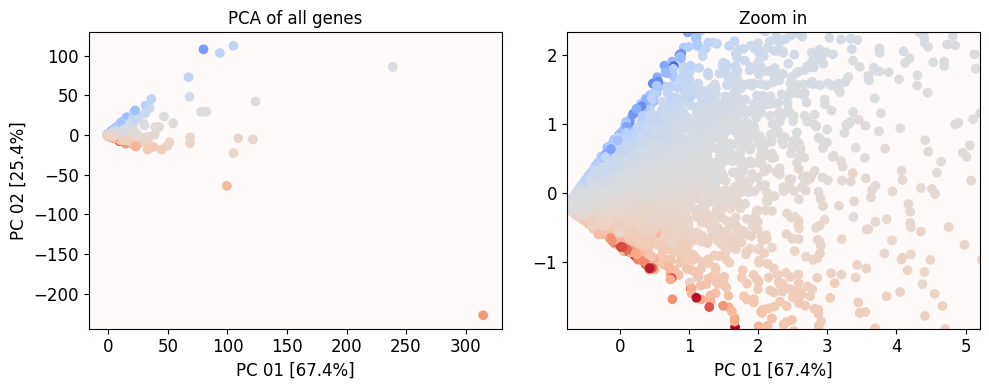

In [13]:
color = nvo
vmax = color.abs().max()
fig, ax = plt.subplots(1,2, figsize=(10,4))

for a in ax.ravel():
    a.scatter(*pca.T, c=color, cmap='coolwarm', marker='o', alpha=1, vmax=vmax, vmin=-vmax)
    a.set_title('PCA of all genes', fontsize=fs)
    a.set_xlabel('PC 01 [{:.1f}%]'.format(explained_ratio[0]), fontsize=fs)
    a.set_facecolor('snow')
    a.tick_params(labelsize=fs)
ax[0].set_ylabel('PC 02 [{:.1f}%]'.format(explained_ratio[1]), fontsize=fs);
ax[1].set_xlim(np.min(pca[:,0]), qs[1,0] + iqr[0])
ax[1].set_ylim(qs[0,1] - iqr[1], qs[1,1] + iqr[1])
ax[1].set_title('Zoom in', fontsize=fs)

fig.tight_layout()

In [28]:
norm = np.sqrt( (tpm**2).sum(axis=1) )
std = tpm.std(axis=1)
sdmean = tpm.std(axis=1)/tpm.mean(axis=1)

model = ensemble.IsolationForest(random_state=42).fit(tpm.values)
iforest = model.decision_function(tpm.values)

corr = tpm.T.corr('pearson')
meancorr = corr.abs().mean(axis=0)

In [35]:
dnorm = np.sqrt( (deseq2**2).sum(axis=1) )
dstd = deseq2.std(axis=1)
dsdmean = deseq2.std(axis=1)/deseq2.mean(axis=1)

dmodel = ensemble.IsolationForest(random_state=42).fit(deseq2.values)
diforest = dmodel.decision_function(deseq2.values)

dcorr = deseq2.T.corr('pearson')
dmeancorr = dcorr.abs().mean(axis=0)

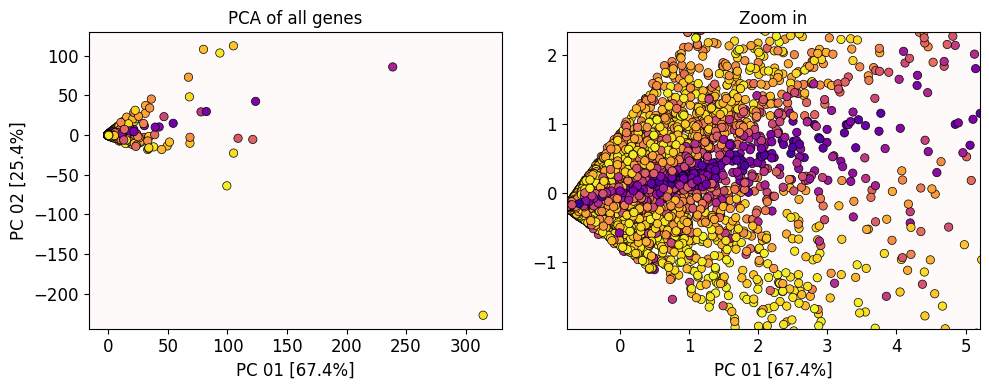

In [19]:
#color = iforest
#color = np.log(norm)
color = medcorr
#vmax = color.abs().max()
fig, ax = plt.subplots(1,2, figsize=(10,4))

for a in ax.ravel():
    a.scatter(*pca.T, c=color, cmap='plasma', ec='k', lw=0.5, marker='o', alpha=1)
    a.set_title('PCA of all genes', fontsize=fs)
    a.set_xlabel('PC 01 [{:.1f}%]'.format(explained_ratio[0]), fontsize=fs)
    a.set_facecolor('snow')
    a.tick_params(labelsize=fs)
ax[0].set_ylabel('PC 02 [{:.1f}%]'.format(explained_ratio[1]), fontsize=fs);
ax[1].set_xlim(np.min(pca[:,0]), qs[1,0] + iqr[0])
ax[1].set_ylim(qs[0,1] - iqr[1], qs[1,1] + iqr[1])
ax[1].set_title('Zoom in', fontsize=fs)

fig.tight_layout()

In [20]:
foo = norm.sort_values(ascending = False).head(15)
nvo[foo.index]

LOC_Os11g47970    2.104131
LOC_Os01g10400   -0.100125
LOC_Os12g17600   -0.086497
LOC_Os12g19381    0.328299
LOC_Os11g07020    1.404250
LOC_Os01g19740   -0.878948
LOC_Os12g02320    0.390528
LOC_Os07g34570   -2.600200
LOC_Os08g10020    0.456415
LOC_Os12g43600   -0.796207
LOC_Os03g01300    0.048634
LOC_Os11g06720   -0.776899
LOC_Os02g02890   -0.034266
LOC_Os06g01210    0.425020
LOC_Os09g17740    0.382581
dtype: float64

In [21]:
avm[foo.index]

LOC_Os11g47970    0.133248
LOC_Os01g10400   -0.123607
LOC_Os12g17600   -0.134543
LOC_Os12g19381   -0.271613
LOC_Os11g07020    0.209718
LOC_Os01g19740   -0.490125
LOC_Os12g02320    0.376139
LOC_Os07g34570   -2.014616
LOC_Os08g10020    0.078185
LOC_Os12g43600   -0.392071
LOC_Os03g01300    0.304858
LOC_Os11g06720   -0.357548
LOC_Os02g02890    0.126086
LOC_Os06g01210   -0.023444
LOC_Os09g17740   -0.158557
dtype: float64

In [22]:
deseq2.loc[foo.index].round(0).astype(int)

,BA24_1,BA24_2,BM24_1,BM24_2,IA24_1,IA24_2,IM24_1,IM24_2,ZA24_1,ZA24_2,...,AG7UI3_count,AG8PX1_count,AG8PX2_count,AG8PX3_count,KITPX1_count,KITPX2_count,KITPX3_count,KITUI1_count,KITUI2_count,KITUI3_count
LOC_Os11g47970,11101,10119,11100,21377,21523,6623,11095,23765,9717,7814,...,1720412,1054324,975020,782200,1498164,1284215,1261585,1710015,1862247,1656824
LOC_Os01g10400,183054,261284,552073,528359,542571,352927,735364,625222,402090,294982,...,477836,452220,357582,411190,499153,366255,425212,463248,528171,383272
LOC_Os12g17600,169907,273218,227330,414264,258620,44851,127105,634460,121356,73482,...,204800,156951,128467,64464,452211,184799,337579,199097,435069,235888
LOC_Os12g19381,124102,164727,220481,290937,140325,30010,78751,345290,75006,41815,...,335001,175580,164173,96059,396995,271555,346973,427470,481723,403564
LOC_Os11g07020,21532,19091,16623,23165,42822,15966,19614,32226,23466,22628,...,779813,654012,484558,461364,707305,530675,622996,609839,836158,552688
LOC_Os01g19740,147717,174249,217568,250133,227371,135975,225404,294798,163677,143788,...,34151,34004,40715,38474,29014,26920,25287,29267,28326,28236
LOC_Os12g02320,21541,22920,12461,23570,54549,54482,35289,40455,34999,37987,...,34790,125301,104843,139071,91339,90046,93907,42603,70774,60479
LOC_Os07g34570,297030,263423,307726,455509,378800,251031,481836,587898,316713,239935,...,422,1180,1341,4814,789,1010,872,833,262,1094
LOC_Os08g10020,49393,65582,80408,98680,101067,35765,66040,135084,48086,35284,...,240982,273549,208259,197224,287424,169330,278473,189578,309906,193485
LOC_Os12g43600,199420,251532,162362,278206,187570,194878,237674,250464,235633,181627,...,29074,35844,23788,40780,36643,34930,44045,38351,28230,38804


In [23]:
scaler = preprocessing.StandardScaler(copy=True, with_std=True, with_mean=True).fit(deseq2)
TPM = scaler.transform(deseq2)

# Let's reduce our data to just 2 dimensions
DPCA = decomposition.PCA(n_components=2, random_state=42, svd_solver='full').fit(TPM)

dpca = DPCA.transform(TPM).astype('float32')
explained_ratio = 100*PCA.explained_variance_ratio_
print(explained_ratio)

[67.39586713 25.44079035]


In [24]:
lab1 = deseq2.columns.str.contains('M24', regex=False) | deseq2.columns.str.contains('UI', regex=False)
lab2 = deseq2.columns[~lab1]
lab1 = deseq2.columns[lab1]

mockavg = deseq2[lab1].median(axis=1)
infavg = deseq2[lab2].median(axis=1)

lab1 = deseq2.columns.str.contains('24_', regex=False)
lab2 = deseq2.columns[~lab1]
lab1 = deseq2.columns[lab1]

oldavg = deseq2[lab1].median(axis=1)
newavg = deseq2[lab2].median(axis=1)


# Store results

In [25]:
tpm.to_csv(src + 'TPM_combined.csv', index=True, index_label='MSU')

In [26]:
deseq2.to_csv(src + 'DESeq2_combined.csv', index=True, index_label='MSU')

In [47]:
fnames = ['TPM Norm', 'TPM IsoForest', 'TPM SD', 'TPM SDmean', 'TPM MeanCorr', 'TPM PC1', 'TPM PC2', 
          'DESeq Norm', 'DESeq IsoForest', 'DESeq SD', 'DESeq SDmean', 'DESeq MeanCorr', 'DESeq PC1', 'DESeq PC2', 
          'DESeq Mock', 'DESeq Attack', 'DESeq Old','DESeq New',
          'LFC New', 'LFC Attack',]
filters = pd.DataFrame(0., index=tpm.index, columns=fnames)
for i,values in enumerate([norm, iforest, std, sdmean, meancorr, *pca.T]):
    filters[fnames[i]] = values
for i,values in enumerate([dnorm, diforest, dstd, dsdmean, dmeancorr, *dpca.T]):
    filters[fnames[7+i]] = values

filters['DESeq Mock'] = mockavg
filters['DESeq Attack'] = infavg
filters['DESeq Old'] = oldavg
filters['DESeq New'] = newavg

filters['LFC New'] = nvo
filters['LFC Attack'] = avm

filters.to_csv(src + 'Combined_gene_filters.csv', index=True, index_label='MSU')

In [44]:
fnames[7]

'DESeq Norm'

In [46]:
filters

,TPM Norm,TPM IsoForest,TPM SD,TPM SDmean,TPM MeanCorr,TPM PC1,TPM PC2,DESeq Norm,DESeq IsoForest,DESeq SD,DESeq SDmean,DESeq MeanCorr,DESeq PC1,DESeq PC2,DESeq Mock,DESeq Attack,DESeq Old,DESeq New,LFC New,LFC Attack
LOC_Os01g01010,131.991057,0.154889,3.580910,0.142340,0.200516,-0.387945,-0.109064,9229.244273,0.134938,268.245908,0.152711,0.332073,-0.079213,-0.014272,1807.670602,1747.729865,1570.033706,1811.693110,0.035152,-0.008280
LOC_Os01g01030,8.835790,0.162671,0.744504,0.484860,0.375902,-0.742786,-0.194563,494.897888,0.158746,40.934130,0.474005,0.317151,-0.923537,-0.315946,79.309941,84.704625,99.657941,73.758702,-0.004354,0.000952
LOC_Os01g01040,105.608376,0.162225,2.493893,0.123604,0.170590,-0.460831,-0.131982,6476.548248,0.144538,171.925034,0.139217,0.374848,-0.338929,-0.120492,1276.838430,1218.435155,1119.522372,1318.972023,0.032436,-0.009263
LOC_Os01g01050,112.109452,0.158991,4.026636,0.189841,0.352453,-0.446085,-0.090538,5224.688847,0.150170,169.317827,0.170740,0.265989,-0.459465,-0.101886,1055.858311,912.440521,996.793774,942.580751,-0.011550,-0.030152
LOC_Os01g01060,635.632145,0.002212,49.213015,0.437872,0.533942,0.988608,0.920886,12866.055596,0.098983,873.984346,0.376264,0.514796,0.316948,0.629754,2273.503221,2220.107633,2864.297905,1595.771044,-0.253927,-0.010317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LOC_Os12g44340,26.536808,0.165831,1.309994,0.265043,0.369903,-0.691407,-0.175518,1419.308572,0.164671,61.474038,0.230757,0.273245,-0.830345,-0.270550,284.280177,255.256346,312.548494,246.685890,-0.011320,-0.005151
LOC_Os12g44360,244.674163,0.108331,14.741738,0.328981,0.479195,-0.088376,-0.204199,27066.989550,-0.004543,1782.958692,0.363393,0.517048,1.471499,-0.098212,4022.100920,5792.562232,3466.737171,6025.186509,0.232787,0.153627
LOC_Os12g44370,198.091347,0.108128,17.566464,0.516619,0.462165,-0.259423,-0.270482,7259.688282,0.130456,691.850091,0.566589,0.472709,-0.384285,-0.365953,937.574763,1412.003396,543.505352,1736.444820,0.351409,0.123904
LOC_Os12g44380,421.618156,0.055545,27.452391,0.358677,0.461771,0.399595,-0.208512,23580.594861,0.021471,1657.731634,0.391297,0.501754,1.154932,-0.137922,3209.040637,5568.485770,2608.257804,5568.485770,0.329298,0.239305


In [42]:
pca

array([[-0.38794547, -0.10906398],
       [-0.7427864 , -0.19456264],
       [-0.4608309 , -0.13198154],
       ...,
       [-0.25942275, -0.270482  ],
       [ 0.39959526, -0.20851232],
       [ 0.1347596 , -0.44716057]], dtype=float32)